In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import lightgbm as lgb
import seaborn as sns
import joblib as jbl
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_parquet("US_accidents_dataset.parquet")
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)

df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour']  = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    if (m == 12 and d >= 24) or (m == 1 and d <= 2): return 1
    if m == 11 and d >= 22:      return 1
    if m == 7  and d == 4:       return 1
    if m == 5  and d >= 25:      return 1
    if m == 9  and d <= 7:       return 1
    if m == 10 and d == 31:      return 1
    if m == 2  and 7 <= d <= 10: return 1
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)', 'Country'], inplace=True)

def time_of_day(h):
    if 6  <= h < 9:  return 0  # morning_rush
    if 9  <= h < 16: return 1  # daytime
    if 16 <= h < 19: return 2  # evening_rush
    if 19 <= h < 23: return 3  # evening
    return 4                   # night

df['time_of_day'] = df['hour'].apply(time_of_day)

# Encoding ciclico mese
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop(columns=['hour', 'month'], inplace=True)

def group_weather(w):
    if pd.isna(w): return 'Unknown'
    w = str(w).lower()
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm', 'tornado', 'funnel']): return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing', 'hail']): return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain', 'drizzle', 'shower']): return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):                                    return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):                 return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):     return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):                                 return 'Clear'
    return 'Other'

def weather_intensity(w):
    if pd.isna(w): return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']): return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):         return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):      return 1
    return 0

df['Weather_Group']     = df['Weather_Condition'].apply(group_weather)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)
df.drop(columns=['Weather_Condition'], inplace=True)

def classify_street(name):
    if pd.isna(name): return 'Unknown'
    name_upper = str(name).upper().strip()
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    if re.match(r'^I-\d+', name_clean):          return 'Interstate'
    if re.match(r'^US-\d+', name_clean):         return 'US_Route'
    if re.match(r'^[A-Z]{2}-\d+', name_clean):  return 'State_Route'
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']): return 'Freeway_Expressway'
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):    return 'Highway'
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):   return 'Parkway'
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']): return 'Boulevard'
    if any(x in name_clean for x in [' AVE', 'AVENUE']):    return 'Avenue'
    if any(x in name_clean for x in [' RD', ' ROAD']):      return 'Road'
    if any(x in name_clean for x in [' ST', ' STREET']):    return 'Street'
    if any(x in name_clean for x in [' DR', ' DRIVE']):     return 'Drive'
    if any(x in name_clean for x in [' LN', ' LANE']):      return 'Lane'
    if any(x in name_clean for x in [' TRL', ' TRAIL']):    return 'Trail'
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']): return 'Local'
    return 'Other'

df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

df.drop(columns=['ID'], inplace=True)
df['desc_length']         = df['Description'].str.len()
df['lanes_blocked']       = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)
df['mentions_closed']     = df['Description'].str.contains(r'closed|closure',         case=False, na=False).astype(int)
df['mentions_blocked']    = df['Description'].str.contains(r'blocked',                case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic',     case=False, na=False).astype(int)
df['mentions_slow']       = df['Description'].str.contains(r'slow traffic',           case=False, na=False).astype(int)
df['mentions_delay']      = df['Description'].str.contains(r'delay|expect delay',     case=False, na=False).astype(int)
df['mentions_shoulder']   = df['Description'].str.contains(r'shoulder',               case=False, na=False).astype(int)
df['unconfirmed']         = df['Description'].str.contains(r'unconfirmed',            case=False, na=False).astype(int)
df['multiple_vehicles']   = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)
df['desc_highway']        = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)
df['drive_caution']       = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed']     = df['Description'].str.contains(r'crash|accident',         case=False, na=False).astype(int)
df.drop(columns=['Description'], inplace=True)

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

df['Sunrise_Sunset'] = (df['Sunrise_Sunset'] == 'Day').astype(int)
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}
df['Wind_Deg']  = df['Wind_Direction'].map(direction_map)
df['Wind_Sin']  = np.where(df['Wind_Deg'] >= 0, np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos']  = np.where(df['Wind_Deg'] >= 0, np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)
df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

source_map = {'Source1': 0, 'Source2': 1, 'Source3': 2}
df['Source'] = df['Source'].map(source_map)

df.drop(columns=[
    'Roundabout', 'Bump', 'Traffic_Calming', 'No_Exit',
    'unconfirmed', 'Amenity', 'Railway', 'Give_Way',
    'multiple_vehicles', 'Station', 'Weather_Windy', 'Timezone'
], inplace=True, errors='ignore')

num_cols = df.select_dtypes(include=['float64', 'float32', 'int64']).columns
num_cols = [c for c in num_cols if c != 'Severity']

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

cols_to_log = ['duration_min', 'Distance(mi)', 'Wind_Speed(mph)', 'desc_length']
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])

if 'Precipitation(in)' in df.columns:
    df['is_raining'] = (df['Precipitation(in)'] > 0).astype(int)
    df.drop(columns=['Precipitation(in)'], inplace=True)

# Alta cardinalità → frequency encoding PRIMA di one-hot
for col in ['City', 'County', 'Zipcode', 'State']:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

# Categoriche → one hot
cat_cols = ['Weather_Group', 'Street_Type']
df = pd.get_dummies(df, columns=cat_cols, dtype=int)

# Riempi i NaN rimasti (frequency encoding, Weather_Intensity, ecc.)
# Per colonne numeriche: usa mediana; per le altre: usa 0
for col in df.columns:
    if col != 'Severity' and df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'float32', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(0)

print(f"Shape dopo preprocessing: {df.shape}")
print(f"NaN rimasti: {df.isnull().sum().sum()}")

Shape dopo preprocessing: (7728394, 65)
NaN rimasti: 0


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
12.4


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

# Split sul DATAFRAME (non array) per preservare le colonne
X_indices = np.arange(len(df))
y = (df['Severity'] - 1).values.astype('int64')

X_temp_idx, X_test_idx, y_temp, y_test = train_test_split(
    X_indices, y, test_size=0.2, random_state=42, stratify=y)

X_train_idx, X_val_idx, y_train, y_val = train_test_split(
    X_temp_idx, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# Ottieni i dataframe
X_train_df = df.iloc[X_train_idx].drop(columns=['Severity'])
X_val_df   = df.iloc[X_val_idx].drop(columns=['Severity'])
X_test_df  = df.iloc[X_test_idx].drop(columns=['Severity'])

print(f"Train: {X_train_df.shape}")
print(f"Val:   {X_val_df.shape}")
print(f"Test:  {X_test_df.shape}")

# KMeans SOLO sul training set (per evitare data leakage)
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_train_df[['Start_Lat', 'Start_Lng']].sample(min(200000, len(X_train_df)), random_state=42))

# Predici i cluster per tutti i set
X_train_df['Geo_Cluster'] = km.predict(X_train_df[['Start_Lat', 'Start_Lng']])
X_val_df['Geo_Cluster']   = km.predict(X_val_df[['Start_Lat', 'Start_Lng']])
X_test_df['Geo_Cluster']  = km.predict(X_test_df[['Start_Lat', 'Start_Lng']])

# Ora converti in array numpy
X_train = X_train_df.values.astype('float32')
X_val   = X_val_df.values.astype('float32')
X_test  = X_test_df.values.astype('float32')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# Converti in tensori e sposta su device
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=4096, shuffle=False)

Usando: cuda
Train: (4946172, 64)
Val:   (1236543, 64)
Test:  (1545679, 64)


In [10]:
# ============================================================
# PARAMETRI RESIDUAL MLP - modifica qui
# ============================================================

# Architettura
HIDDEN_DIM    = 512    # dimensione dei residual block
NUM_BLOCKS    = 5      # numero di residual block
DROPOUT_RATES = [0.3, 0.3, 0.2, 0.2, 0.1]  # uno per block

# Training
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
BATCH_SIZE    = 2048
MAX_EPOCHS    = 150
PATIENCE      = 20
SCALE_CLASS0  = 1.2
SCALE_CLASS3  = 1.1

# Focal Loss
GAMMA = 1.0

# Scheduler
SCHEDULER_PATIENCE = 8
SCHEDULER_FACTOR   = 0.5

from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        return self.relu(x + self.block(x))  # skip connection

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_blocks, dropout_rates):
        super().__init__()
        
        # Proiezione input → hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0])
        )
        
        # Residual blocks
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(hidden_dim, dropout_rates[i])
            for i in range(num_blocks)
        ])
        
        # Output
        self.output = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rates[-1]),
            nn.Linear(hidden_dim // 2, 4)
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.output(x)

In [12]:
input_dim = X_train.shape[1]
model_nn  = ResidualMLP(input_dim, HIDDEN_DIM, NUM_BLOCKS, DROPOUT_RATES).to(device)
print(f"Architettura Residual MLP:")
print(model_nn)
print(f"\nParametri totali: {sum(p.numel() for p in model_nn.parameters()):,}")
print(f"Input features:   {input_dim}")

class_counts    = np.bincount(y_train)
weights         = 1.0 / class_counts
weights[0]     *= SCALE_CLASS0
weights[3]     *= SCALE_CLASS3
weights         = weights / weights.sum()
weights         = weights * 4
weights_tensor  = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model_nn.parameters(),
                              lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min',    
                patience=SCHEDULER_PATIENCE,
                factor=SCHEDULER_FACTOR,
                verbose=True)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),                          batch_size=BATCH_SIZE, shuffle=False)

Architettura Residual MLP:
ResidualMLP(
  (input_proj): Sequential(
    (0): Linear(in_features=65, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=512, out_features=512, bias=True)
        (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): R

c:\Users\matti\University\ProgettoColloquio\Project_Security_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [13]:
best_val_f1   = 0
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print("\nInizio training...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Macro F1':>12} | {'LR':>8}")
print("-" * 60)

for epoch in range(MAX_EPOCHS):
    # Train
    model_nn.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs    = model_nn(X_batch)
        loss       = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model_nn.eval()
    val_preds, val_true = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs   = model_nn(X_batch)
            loss      = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds     = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())
    
    val_f1     = f1_score(val_true, val_preds, average='macro')
    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_f1'].append(val_f1)
    
    # Scheduler basato su val loss (più stabile)
    scheduler.step(avg_val)
    
    print(f"{epoch+1:>6} | {avg_train:>10.4f} | {avg_val:>10.4f} | {val_f1:>12.4f} | {current_lr:>8.6f}")
    
    # Salva il modello con F1 migliore
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_nn.state_dict(), 'best_residual_mlp_2.pt')
        print(f"         → Salvato nuovo miglior F1: {best_val_f1:.4f}")
    
    # Early stopping basato su val loss
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Miglior Val Loss: {best_val_loss:.4f}")
            print(f"Miglior Val F1:   {best_val_f1:.4f}")
            break

print(f"\nMiglior Val Macro F1: {best_val_f1:.4f}")
print(f"Miglior Val Loss:     {best_val_loss:.4f}")


Inizio training...
 Epoch | Train Loss |   Val Loss | Val Macro F1 |       LR
------------------------------------------------------------
     1 |     0.3931 |     0.3261 |       0.5821 | 0.000300
         → Salvato nuovo miglior F1: 0.5821
     2 |     0.3328 |     0.3042 |       0.5912 | 0.000300
         → Salvato nuovo miglior F1: 0.5912
     3 |     0.3176 |     0.2960 |       0.6019 | 0.000300
         → Salvato nuovo miglior F1: 0.6019
     4 |     0.3078 |     0.2927 |       0.6111 | 0.000300
         → Salvato nuovo miglior F1: 0.6111
     5 |     0.3010 |     0.2877 |       0.6001 | 0.000300
     6 |     0.2954 |     0.2838 |       0.6079 | 0.000300
     7 |     0.2920 |     0.2797 |       0.6127 | 0.000300
         → Salvato nuovo miglior F1: 0.6127
     8 |     0.2879 |     0.2767 |       0.6112 | 0.000300
     9 |     0.2846 |     0.2757 |       0.6162 | 0.000300
         → Salvato nuovo miglior F1: 0.6162
    10 |     0.2817 |     0.2726 |       0.6147 | 0.000300
    11


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.17      0.91      0.29     13473
  Severity 2       0.99      0.84      0.91   1231396
  Severity 3       0.70      0.92      0.80    259868
  Severity 4       0.44      0.95      0.60     40942

    accuracy                           0.86   1545679
   macro avg       0.57      0.91      0.65   1545679
weighted avg       0.92      0.86      0.87   1545679



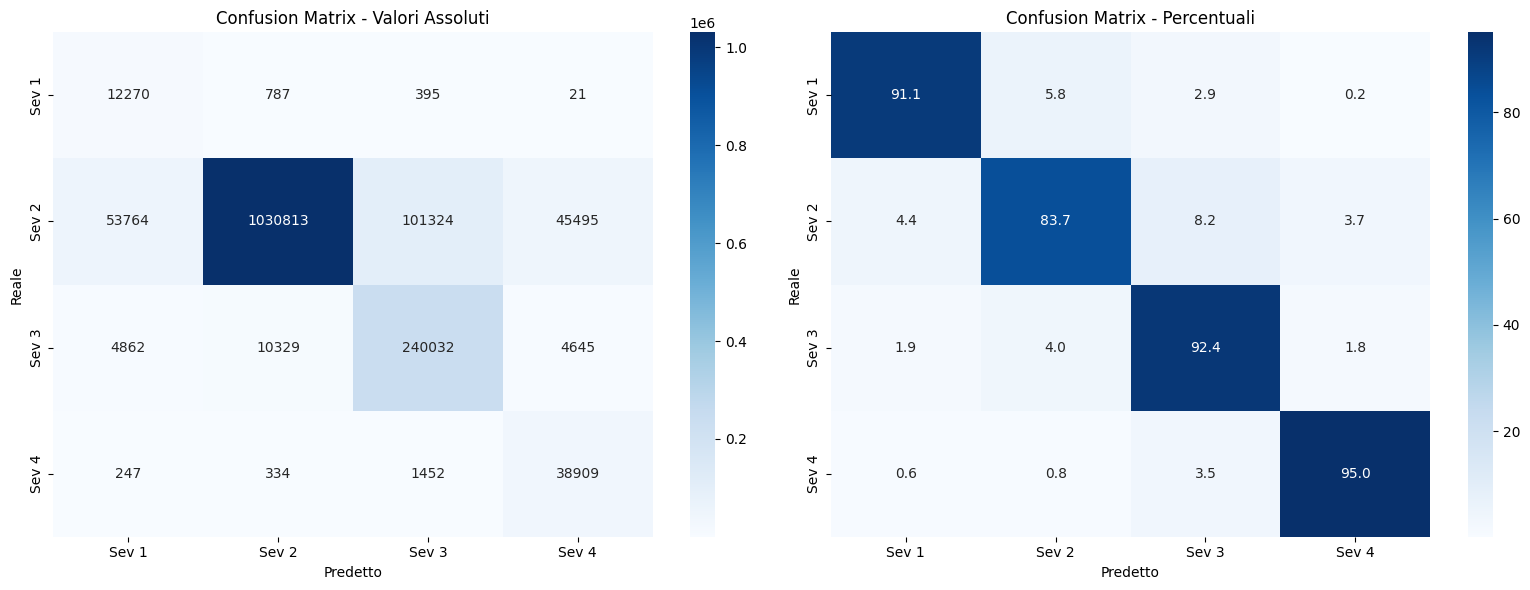

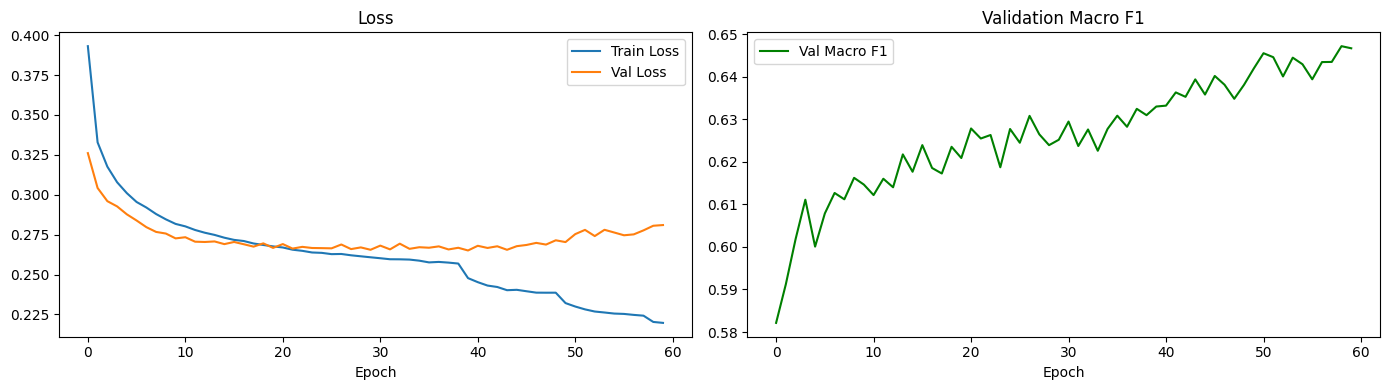

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model_nn.load_state_dict(torch.load('best_residual_mlp_2.pt'))
model_nn.eval()

test_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_nn(X_batch)
        preds   = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, test_preds,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import joblib as jbl
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# RICOSTRUISCI IL MODELLO E CARICA I PESI
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

input_dim = X_train.shape[1]
model_nn  = ResidualMLP(input_dim, HIDDEN_DIM, NUM_BLOCKS, DROPOUT_RATES).to(device)
model_nn.load_state_dict(torch.load('best_residual_mlp_2.pt', map_location=device))
model_nn.eval()
print(f"Modello caricato! Input dim: {input_dim}")

# ============================================================
# FUNZIONE PER ESTRARRE PROBABILITÀ
# ============================================================
def get_probs(loader, model, device):
    probs_list = []
    with torch.no_grad():
        for (batch,) in loader:
            batch   = batch.to(device)
            outputs = model(batch)
            probs   = torch.softmax(outputs, dim=1)
            probs_list.append(probs.cpu().numpy())
    return np.concatenate(probs_list)

# ============================================================
# DATALOADER SENZA LABEL (solo X)
# ============================================================
val_loader_x  = DataLoader(TensorDataset(X_val_t),
                            batch_size=4096, shuffle=False)
test_loader_x = DataLoader(TensorDataset(X_test_t),
                            batch_size=4096, shuffle=False)

# ============================================================
# CALCOLA E SALVA PROBABILITÀ
# ============================================================
print("Calcolo probabilità su val set...")
nn_val_probs = get_probs(val_loader_x, model_nn, device)
jbl.dump(nn_val_probs, 'nn_val_probs_2.pkl')
print(f"Val probs salvate! Shape: {nn_val_probs.shape}")

print("Calcolo probabilità su test set...")
nn_test_probs = get_probs(test_loader_x, model_nn, device)
jbl.dump(nn_test_probs, 'nn_test_probs_2.pkl')
print(f"Test probs salvate! Shape: {nn_test_probs.shape}")

# Salva anche lo scaler per usi futuri
jbl.dump(scaler, 'nn_scaler_2.pkl')
print("Scaler salvato!")

Usando: cuda
Modello caricato! Input dim: 65
Calcolo probabilità su val set...
Val probs salvate! Shape: (1236543, 4)
Calcolo probabilità su test set...
Test probs salvate! Shape: (1545679, 4)
Scaler salvato!
